# Generating AG news data

**Table of contents**:
- Qwen/Qwen2.5-0.5B-Instruct  
    1. Baseline
    2. Targeted
    3. Targeted + Linguistic tags
- deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B  
    1. Baseline
    2. Targeted
    3. Targeted + Linguistic tags
    4. Unsupervised context
- meta-llama/Llama-2-7b-chat-hf
    1. Baseline
    2. Targeted
    3. Targeted + Linguistic tags
    4. Unsupervised context

Links:
- https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct
- https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
- https://huggingface.co/meta-llama/Llama-2-7b-hf
- https://huggingface.co/meta-llama/Llama-2-7b-chat-hf


**Results**:
- The task seems easier than irony detection. The <text, label> pairs are more coherent.
- DeepSeek gave better performance than QWEN. It did a better job of obeying the restrictions on the number of examples to be output and the labels to be specified.
- Even when the linguistic tags need to be specified, the model gives reasonable results and follows the structure of the output well.
- The results are focused on less specific topics than the results given by chatgpt.
- Some samples created are in between different labels:
    - "The World is set to host the next FIFA World Cup..." World & Sport    
    - "A major tech company has announced a new venture that aims to revolutionize the business of artificial intelligence..." Business & Sci/Tech
- Llama-2-7b-chat-hf follows well the instuctions when using the chat template.

In [1]:
import os

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, LlamaTokenizer, LlamaForCausalLM, BitsAndBytesConfig
import pandas as pd
import re
import numpy as np
from src._utils._helpers import log_synthetic_data, response2json, get_response, set_seed, clear_cuda_cache, get_context_examples

HF_TOKEN = open("src/_utils/hf_token.txt","r").read() # your huggingface token

In [2]:
# Create the folder to save the synthetic data
folder_name = "synthetic_data/logs"
os.makedirs(folder_name, exist_ok=True)

# file where the logs will be saved
log_file_path = folder_name + "/agnews_log.json"
RECREATE_LOG = False
if os.path.exists(log_file_path) and RECREATE_LOG:
    os.remove(log_file_path) # recreate from scratch

# DEVICE
device = 'cuda:0'
model = None

# DATA
df = pd.read_csv("real_data/train/agnewstrainAll.csv")
df = df.rename(columns={"2": "text", "3": "label"})
display(df.head())

labels_lst = df['label'].unique()
labels_str = ", ".join(labels_lst)
labels_str_bullet = "\n".join([f"- {name}" for name in labels_lst])
labels_str_bullet_bold = "\n".join([f"- **{name}**" for name in labels_lst])
print(f"Labels: {labels_str}")

# Print the first example for each label
examples = []
for label in labels_lst:
    example = (df[df['label'] == label].iloc[0]).loc['text']
    examples.append(example)
    print(f"Label: {label}\nText: {example}\n")

,0,1,text,label
0,1000_train,Hartford executive #39;s stock sale probed,New York AG is investigating the timing of a s...,Business
1,1001_train,Cool Batman Photo!,"In related news, it was announced yesterday th...",Sci/Tech
2,1002_train,Stocky Monkey in Himalayas Becomes Newest Prim...,Scientists from India working in the Himalayas...,Sci/Tech
3,1003_train,"Bush, Kerry Don''t Worry About Tech","Election Day is less than two weeks away, but ...",Sci/Tech
4,1004_train,The Teeming Crowd in Video Games,"Jeffrey Griffiths, the president and chief exe...",Sci/Tech


Labels: Business, Sci/Tech, Sports, World
Label: Business
Text: New York AG is investigating the timing of a sale by Thomas Marra; company reports higher 3Q. NEW YORK (Reuters) - The Hartford Financial Services Group Inc.

Label: Sci/Tech
Text: In related news, it was announced yesterday that Warner Bros. Interactive Entertainment, DC Comics and Electronic Arts will bring a Batman Begins videogame tie-in.

Label: Sports
Text: Lindsay Davenport #39;s world number one ranking is in doubt after she failed to make the finals of the WTA Tour Championships in Los Angeles.

Label: World
Text:  JERUSALEM (Reuters) - Israeli Prime Minister Ariel Sharon  accused far-rightists Sunday of trying to incite civil war over  his plan to withdraw from the occupied Gaza Strip and called  for measures to curb such groups.



# Qwen/Qwen2.5-0.5B-Instruct
## 1. Baseline

In [3]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map=device,
    attn_implementation='flash_attention_2',
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# for qwen we use this system prompt:
system_prompt_qwen = "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, distributed across the following four News categories:  
{labels_str_bullet_bold}

### **Guidelines:**  
- Ensure **each category has 2-3 representative examples**.  
- The text should be **realistic and concise**, resembling real-world news snippets.  
- Cover **diverse topics within each category**.

### **Output Format (JSON)**  
Return **only** a valid JSON list in the following structure:

```json
[
    {{"text": "{examples[0]}", "label": "{labels_lst[0]}"}},
    {{"text": "{examples[1]}", "label": "{labels_lst[1]}"}},
    {{"text": "{examples[2]}", "label": "{labels_lst[2]}"}},
    {{"text": "{examples[3]}", "label": "{labels_lst[3]}"}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer, system_prompt=system_prompt_qwen)

TIME TAKEN: 3.33
GENERATED RESPONSE:
```json
[
    {
        "text": "New York AG is investigating the timing of a sale by Thomas Marra; company reports higher 3Q.",
        "label": "Business"
    },
    {
        "text": "In related news, it was announced yesterday that Warner Bros. Interactive Entertainment, DC Comics and Electronic Arts will bring a Batman Begins videogame tie-in.",
        "label": "Sci/Tech"
    },
    {
        "text": "Lindsay Davenport's world number one ranking is in doubt after she failed to make the finals of the WTA Tour Championships in Los Angeles.",
        "label": "Sports"
    },
    {
        "text": "Israeli Prime Minister Ariel Sharon accused far-rightists Sunday of trying to incite civil war over his plan to withdraw from the occupied Gaza Strip and called for measures to curb such groups.",
        "label": "World"
    }
]
```


Answers are too similar to the examples given.

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in **news classification**. \
Your task is to generate 10 high-quality short documents. \
The category of the news is the label of interest. The distribution of the labels should be balanced.\
The labels are the following:  
{labels_str_bullet_bold}

### Output Format (JSON)  
Return only a valid JSON list of 10 items in the following structure:

```json
[
    {{"text": <text>, "label": <label>}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer, system_prompt=system_prompt_qwen)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "baseline", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 3.39
GENERATED RESPONSE:
```json
[
    {
        "text": "Apple Inc. announces new iPhone models for next year.",
        "label": "Tech"
    },
    {
        "text": "Tesla unveils new electric vehicle model.",
        "label": "Tech"
    },
    {
        "text": "Amazon launches new product line.",
        "label": "Tech"
    },
    {
        "text": "Microsoft releases new version of its Windows operating system.",
        "label": "Tech"
    },
    {
        "text": "Google introduces new AI-powered assistant.",
        "label": "Tech"
    },
    {
        "text": "Facebook launches new mobile app for business users.",
        "label": "Tech"
    },
    {
        "text": "NVIDIA introduces new graphics processing unit.",
        "label": "Tech"
    },
    {
        "text": "Uber announces new driver recruitment program.",
        "label": "Tech"
    },
    {
        "text": "Airbnb expands global presence.",
        "label": "Tech"
    },
    {
        "text": "Lululemo

## 2. Targeted synthetic data

Here the topics that needs to be covered are asked directly to this LLM

In [6]:
prompt = f"""\
You are an expert News reporter and NLP enthusiast. \
List key linguistic, semantic, and contextual phenomena that characterize News documents.

Return only a **short* list in a simple bullet-point format.\
"""
news_aspects, delta_t_0 = get_response(prompt, model, tokenizer, system_prompt=system_prompt_qwen)

TIME TAKEN: 4.21
GENERATED RESPONSE:
- **Language Use**: The use of specific vocabulary and grammar structures common in news writing.
- **Contextual Information**: The context provided about the topic, such as the time, date, location, and subject matter.
- **Topic Clarity**: The clarity with which the article presents its main points.
- **Fact Verification**: The accuracy and reliability of information presented.
- **Sarcasm and Irony**: The presence or absence of sarcasm or irony in the text.
- **Vocabulary**: Words and phrases used to describe events, people, places, and ideas in detail.
- **Emotional Tone**: The emotional tone of the piece, whether it is informative, persuasive, or entertaining.
- **Credibility**: The author's credibility and expertise on the topic being discussed.
- **Grammar and Structure**: The adherence to standard English grammar rules and sentence structure.
- **Hyperbole**: The exaggeration or overstatement of facts without justification.
- **Synesthesia**:

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, that talks about the following four News categories (labels):  
{labels_str_bullet_bold}

### **Guidelines:**
{news_aspects}

### **Output Format (JSON)**
The labels must be one of the specified categories. Return only a valid JSON list in the following structure:

```json
[
    {{"text": <text>, "label": <label>}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer, system_prompt=system_prompt_qwen)
# synthetic_data = response2json(response)
# log_synthetic_data(model_name, "targeted", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 2.52
GENERATED RESPONSE:
```json
[
    {
        "text": "In the bustling city of Tokyo, the annual E3 trade fair attracts thousands of visitors each year, showcasing the latest technology and products from around the world.",
        "label": "Tech"
    },
    {
        "text": "The epicenter of the global financial crisis was the collapse of Lehman Brothers, a major financial institution that had been heavily invested in mortgage-backed securities.",
        "label": "Sci/Tech"
    },
    {
        "text": "The vibrant city of Paris hosted the 2024 Summer Olympics, where athletes from all over the world competed in various sports.",
        "label": "Sport"
    },
    {
        "text": "In the heart of New York City, the iconic Statue of Liberty stands as a symbol of freedom and democracy.",
        "label": "World"
    }
]
```


### Targeted synthetic data with Chat-GPT

The topics that need to be covered are generated from Chat-GPT online.

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, that talks about the following four News categories (labels):  
{labels_str_bullet_bold}

### **Follow these topics:**
- **Business**  
  - Markets  
  - Economy  
  - Companies  
  - Startups  
  - Regulations  

- **Sci/Tech**  
  - AI  
  - Space  
  - Cybersecurity  
  - Biotech  
  - Climate  

- **Sports**  
  - Events  
  - Records  
  - Highlights  
  - Scandals  
  - Olympics  

- **World**  
  - Politics  
  - Conflicts  
  - Disasters  
  - Human Rights  
  - Trade

### **Output Format (JSON)**
The labels must be one of the specified categories, which are: {labels_str}. \
Return only a valid JSON list of 10 elements in the following structure:

```json
[
    {{"text": <news document>, "label": <corresponding label>}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer, system_prompt=system_prompt_qwen)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "targeted", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 3.84
GENERATED RESPONSE:
```json
[
    {
        "text": "Market Trends Analysis: Global Stock Market Performance",
        "label": "Business"
    },
    {
        "text": "AI Breakthroughs: The Latest Developments in Artificial Intelligence",
        "label": "Sci/Tech"
    },
    {
        "text": "Space Exploration: Future Prospects for Mars Missions",
        "label": "Sci/Tech"
    },
    {
        "text": "Cybersecurity Threats: How to Stay Safe Online",
        "label": "Sci/Tech"
    },
    {
        "text": "Biotechnology Advances: Future Medical Innovations",
        "label": "Sci/Tech"
    },
    {
        "text": "Climate Change: Solutions for Mitigation and Adaptation",
        "label": "Sci/Tech"
    },
    {
        "text": "Events: The Best Newscasts of the Week",
        "label": "Sports"
    },
    {
        "text": "Records: The Unforgettable Moments of the Day",
        "label": "Sports"
    },
    {
        "text": "Olympics Highlights: The Most Exciti

## 3. Targeted + Tags linguistic phenomena 

Now we ask to the model also to identify the linguistic phenomena present in the generated sentence.

```
{  
    "text": "Oh, I absolutely adore being stuck in traffic for hours.",   
    "label": "ironic",  
    "phenomena": ["Polarity inversion", "Hyperbole", "Semantic incongruence", "Lexical exaggeration"]
},
```

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality **short documents**, that talks about the following four News categories (labels):  
{labels_str_bullet_bold}.
For each example, also list the key phenomena it covers.

### **Follow these topics:**
- **Business**  
  - Markets  
  - Economy  
  - Companies  
  - Startups  
  - Regulations  

- **Sci/Tech**  
  - AI  
  - Space  
  - Cybersecurity  
  - Biotech  
  - Climate  

- **Sports**  
  - Events  
  - Records  
  - Highlights  
  - Scandals  
  - Olympics  

- **World**  
  - Politics  
  - Conflicts  
  - Disasters  
  - Human Rights  
  - Trade

### **Output Format (JSON)**
The labels must be one of the specified categories, which are: {labels_str}. \
Return only a valid JSON list of 10 elements in the following structure:

```json
[
    {{"text": <news document>, "label": <corresponding label>, "phenomena": ["<phenomenon1>", "<phenomenon2>", ...]}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer, system_prompt=system_prompt_qwen)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "targeted + linguistic tags", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 5.86
GENERATED RESPONSE:
```json
[
    {
        "text": "Market Trends Analysis: Global Stock Market Performance",
        "label": "Business",
        "phenomena": ["Stock market performance", "Economic indicators"]
    },
    {
        "text": "Space Exploration: SpaceX Launches New Mission",
        "label": "Sci/Tech",
        "phenomena": ["Space exploration", "Rocket launches", "Technology advancements"]
    },
    {
        "text": "Cybersecurity Threats: Latest Infections in IoT Devices",
        "label": "Sci/Tech",
        "phenomena": ["Intrusion detection systems", "IoT devices", "Security threats"]
    },
    {
        "text": "Climate Change: The Impact on Agriculture",
        "label": "Sci/Tech",
        "phenomena": ["Agriculture practices", "Climate change impacts", "Solutions for sustainable agriculture"]
    },
    {
        "text": "Olympic Games: Highlights of the 2022 Tokyo Games",
        "label": "Sports",
        "phenomena": ["Events", "Record-br

---

# deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B

In [9]:
clear_cuda_cache(model)

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map=device,
    attn_implementation='flash_attention_2',
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.generation_config.pad_token_id = tokenizer.pad_token_id

## 1. Baseline

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, distributed across the following four News categories:  
{labels_str_bullet_bold}

### **Guidelines:**  
- Ensure each category has 2-3 representative examples.  
- The text should be realistic and concise, resembling real-world news snippets.  
- Cover diverse topics within each category.

### **Output Format (JSON)**  
Return **only** a valid JSON list in the following structure:

```json
[
    {{"text": "{examples[0]}", "label": "{labels_lst[0]}"}},
    {{"text": "{examples[1]}", "label": "{labels_lst[1]}"}},
    {{"text": "{examples[2]}", "label": "{labels_lst[2]}"}},
    {{"text": "{examples[3]}", "label": "{labels_lst[3]}"}},
    ...
]
```
"""
generated, delta_t = get_response(prompt, model, tokenizer)

TIME TAKEN: 16.73
GENERATED RESPONSE:
Okay, so I need to generate 10 short news documents across four categories: Business, Sci/Tech, Sports, and World. Let me think about how to approach each category and come up with relevant examples.

Starting with Business. I should find news that's related to business operations or financial news. Maybe something about a company's recent actions or financial figures. I can't just make up anything, so I'll look for well-known companies or events in the business sector.

Next, Sci/Tech. This category needs scientific or technological news. I should think about recent advancements, breakthroughs, or interesting experiments in fields like AI, space exploration, or quantum computing. It's important to include both successes and maybe some controversies or innovations.

For Sports, I'll need news related to sports events, player news, or team developments. Maybe something about a new record, a significant injury, or a major tournament result. It's cruc

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, that talks about the following four News categories:  
{labels_str_bullet_bold}

### **Output Format (JSON)**  
Return only a valid JSON list of 10 items in the following structure:

```json
[
    {{"text": <text>, "label": <label>}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "baseline", prompt, synthetic_data, delta_t, output_file=log_file_path)


TIME TAKEN: 19.43
GENERATED RESPONSE:
Okay, so the user has asked me to generate 10 high-quality short news documents for four categories: Business, Sci/Tech, Sports, and World. They mentioned that I'm an expert in journalism and NLP, so I can use advanced techniques to create these documents. 

First, I need to make sure each document is concise and informative. The user specified JSON format, so I'll structure each item as an object with "text" and "label" keys. I should vary the topics within each category to cover a broad range of news.

For the Business category, I can think of articles about tech companies, maybe a merger, or a major financial event. A business article about a new tech start-up could be good. Then, a financial article on a major event like the US election would fit well.

Next, Sci/Tech is all about science and technology. I can create a news piece about groundbreaking research, maybe a recent breakthrough in AI. Also, an article on climate change could be releva

Some samples created are in between different labels:

"The World is set to host the next FIFA World Cup..." World & Sport  
"A new AI system has been developed..." Business & Sci/Tech  
"A major tech company has announced a new venture that aims to revolutionize the business of artificial intelligence..." Business & Sci/Tech

## 2. Targeted

In [13]:
prompt = f"""\
You are an expert News reporter and NLP enthusiast. \
List all key topics that must be covered in News document.\
In particular consider the following categories: {labels_str}
Return only a short list in a simple bullet-point format.\
"""
news_aspects, delta_t_0 = get_response(prompt, model, tokenizer)

TIME TAKEN: 10.12
GENERATED RESPONSE:
Okay, so I need to list the key topics that must be covered in a News Document, specifically broken down into Business, Sci/Tech, Sports, and World categories. The user wants a simple bullet-point format with only the categories, no subcategories. 

Starting with Business, I know there are major topics like the economy, especially the global economy and maybe tech companies. Then, global politics, international relations, and corporate governance come to mind. Also, consumer trends and consumer behavior are important. Marketing strategies and consumer perception are key areas too. International business and trade policy are definitely relevant. And the global economy's growth and challenges.

Moving on to Sci/Tech, the focus would be on innovation and advancements. The rise of AI and machine learning is a big one. Quantum computing and its potential impact is another. Renewable energy and sustainable development are crucial. AI in healthcare and it

In [14]:
# Extract bullet points
news_aspects = re.findall(r"- (.+)", news_aspects)
news_aspects = set([b.strip() for b in news_aspects])  # Remove leading/trailing whites and duplicates

# Convert to CSV string
news_aspects = ", ".join(news_aspects)
print(f"News aspects: {news_aspects}")

News aspects: **Sci/Tech**: Innovation and advancements, AI and machine learning, quantum computing, renewable energy, healthcare AI, climate change, emerging tech trends, future of tech., **Sports**: World Cup, world records, sports statistics, international sports news, athletes performance, sports strategies, World Cup analysis, game rules., **World**: pandemic impact, international relations, global governance, digital IoT, global economy, COVID-19 impact, population growth, global economy challenges., **Business**: Global economy trends, international politics, corporate governance, consumer behavior, marketing strategies, international business, trade policy, economic growth and challenges.


In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, that talks about the following four News categories (labels):  
{labels_str_bullet_bold}

### **Guidelines:**
{news_aspects}

### **Output Format (JSON)**
Return only a valid JSON list of 10 items in the following structure:

```json
[
    {{"text": <text>, "label": <label>}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer)
# synthetic_data = response2json(response)
# log_synthetic_data(model_name, "targeted", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 16.44
GENERATED RESPONSE:
Okay, so the user has asked me to generate 10 short news documents for four specific categories: Business, Sci/Tech, Sports, and World. They provided detailed guidelines on what each category includes, which is really helpful. 

First, I need to make sure I understand each category correctly. For Business, it's about global economy trends, international politics, corporate governance, etc. Sci/Tech includes AI, quantum computing, renewable energy, etc. Sports focuses on World Cup, sports stats, strategies, etc. World covers pandemic impacts, international relations, economy, population, etc.

I should think of topics that fit each category well. For example, under Business, maybe something about global trade or corporate social responsibility. Sci/Tech could involve AI in healthcare or climate change. Sports might have articles about a tournament or athlete performance. World could focus on the COVID-19 pandemic or population growth.

I need to ens

### Targeted synthetic data with Chat-GPT

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, that talks about the following four News categories (labels):  
{labels_str_bullet_bold}

### **Follow these topics:**
- **Business**  
  - Markets  
  - Economy  
  - Companies  
  - Startups  
  - Regulations  

- **Sci/Tech**  
  - AI  
  - Space  
  - Cybersecurity  
  - Biotech  
  - Climate  

- **Sports**  
  - Events  
  - Records  
  - Highlights  
  - Scandals  
  - Olympics  

- **World**  
  - Politics  
  - Conflicts  
  - Disasters  
  - Human Rights  
  - Trade

### **Output Format (JSON)**
The labels must be one of the specified categories, which are: {labels_str}. \
Return only a valid JSON list of 10 elements in the following structure:

```json
[
    {{"text": <text of the document>, "label": <corresponding label>}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "targeted", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 14.14
GENERATED RESPONSE:
Okay, so the user has asked me to generate 10 short news documents for four different categories: Business, Sci/Tech, Sports, and World. They provided specific topics for each category, and I need to make sure each document is tailored to those topics. 

First, I need to understand each category's focus. Business should cover markets, economy, companies, startups, and regulations. Sci/Tech is AI, space, cybersecurity, biotech, and climate. Sports needs to talk about events, records, highlights, scandals, and Olympics. World includes politics, conflicts, disasters, human rights, and trade.

I should brainstorm some topics within each category that are current and relevant. For Business, maybe something about the tech sector's impact on markets. For Sci/Tech, perhaps the latest AI advancements. Sports could focus on an Olympic event with a highlight. World might involve a political event or conflict.

I need to ensure each document is concise and cap

## 3. Targeted + Tags linguistic phenomena 

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, that talks about the following four News categories (labels):  
{labels_str_bullet_bold}.
For each example, also list the key phenomena it covers.

### **Follow these topics:**
- **Business**  
  - Markets  
  - Economy  
  - Companies  
  - Startups  
  - Regulations  

- **Sci/Tech**  
  - AI  
  - Space  
  - Cybersecurity  
  - Biotech  
  - Climate  

- **Sports**  
  - Events  
  - Records  
  - Highlights  
  - Scandals  
  - Olympics  

- **World**  
  - Politics  
  - Conflicts  
  - Disasters  
  - Human Rights  
  - Trade

### **Output Format (JSON)**
The labels must be one of the specified categories, which are: {labels_str}. \
Return only a valid JSON list of 10 elements in the following structure:

```json
[
    {{"text": <text of the document>, "label": <corresponding label>, "phenomena": ["<phenomenon1>", "<phenomenon2>", ...]}},
    ...
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "targeted + linguistic tags", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 17.92
GENERATED RESPONSE:
Okay, so the user has asked me to generate 10 short news documents for four different categories: Business, Sci/Tech, Sports, and World. Each document should cover specific phenomena within its category. Let me break this down step by step.

First, I need to understand what each category entails. For Business, topics include markets, economy, companies, startups, and regulations. Sci/Tech covers AI, space, cybersecurity, biotech, and climate. Sports focuses on events, records, Highlights, and scandals, while World includes politics, conflicts, disasters, and human rights.

I should come up with 10 unique topics that touch on these areas. Let me brainstorm some ideas for each category.

In Business, maybe something about the global economy, tech companies, or regulations. For Sci/Tech, AI in healthcare or space exploration. Sports could involve a sports event or a scandal. World might include politics or conflicts.

I need to ensure each document is

### Example of data generated by Chat-GPT

- Text is more realistic and focused on more specific topic

"text": "Global stock markets experienced a sharp rise today as tech giants posted record profits. Analysts predict continued growth driven by AI advancements and cloud computing.",  
"label": "Business",  
"phenomena": ["Markets", "Companies"]  
 
"text": "A breakthrough in AI-powered drug discovery has led to the rapid identification of new antibiotics, potentially revolutionizing treatment for antibiotic-resistant bacteria.",  
"label": "Sci/Tech",  
"phenomena": ["AI", "Biotech"]  

"text": "The UEFA Champions League final ended in dramatic fashion as Real Madrid secured a last-minute victory over Manchester City, marking their 15th title win.",  
"label": "Sports",  
"phenomena": ["Events", "Records"]  

"text": "Following a major cyberattack on a multinational bank, security experts warn of growing threats targeting financial institutions worldwide.",  
"label": "Sci/Tech",  
"phenomena": ["Cybersecurity", "Companies"]  

"text": "New US economic policies aimed at reducing inflation include increased interest rates and stricter fiscal measures, sparking debates among economists.",  
"label": "Business",  
"phenomena": ["Economy", "Regulations"]  

"text": "NASA has successfully launched its latest Mars rover, designed to search for signs of ancient microbial life and test new space exploration technologies.",  
"label": "Sci/Tech",  
"phenomena": ["Space", "Climate"]  

"text": "A doping scandal has rocked the world of professional athletics, with several top runners suspended after testing positive for banned substances.",  
"label": "Sports",  
"phenomena": ["Scandals", "Records"]  

"text": "A massive earthquake struck Southeast Asia, causing widespread destruction and prompting international aid efforts to support affected communities.",  
"label": "World",  
"phenomena": ["Disasters", "Human Rights"]  

"text": "Trade negotiations between the EU and South America have reached a breakthrough, paving the way for a new economic partnership that could boost global commerce.",  
"label": "World",  
"phenomena": ["Trade", "Politics"]  

"text": "Amid rising geopolitical tensions, world leaders gather for an emergency summit to address conflicts and work towards diplomatic solutions.",  
"label": "World",  
"phenomena": ["Politics", "Conflicts"]  


## 4. Unsupervised Context

We give to the prompt a set of documents as prompts. this documents are picket randomly from the train set, and are given without the corresponding label.

In [33]:
# get n examples randomly
def get_n_examples(n, df):
    return df.sample(n=n, random_state=42).to_dict(orient="records")

examples = get_n_examples(15, df)
for i, item in enumerate(examples):
    print(item['text'])
    print("\n")
    if (i + 1) % 5 == 0 and i != 0:
        print("========================================")
        print("\n")

The combined worldwide market for desktops, servers and packaged software running on Linux is forecast to grow at a 2003-2008 compound annual growth rate of 25.9 percent worldwide, reaching \$35.7 billion by 2008.


A SECOND-HALF Springbok blitz gave South Africa their first Tri-Nations rugby title in six years with a win over Australia at Kings Park.


It #39;ll cost about the same as the regular-sized PS 2 in the US and Europe. The smaller PlayStation 2 has all regular PlayStation 2 functions such as playing CDs and DVDs.


Three British nationals were nabbed by gunmen in the Iraqi capital on Thursday, the Iraqi Interior Ministry said. The three British men were believed to be civilians living 


AP - Seattle and Miami are among the NBA''s four winningest teams so far this season, ranking just behind Phoenix and San Antonio. Yet when the Heat put their 14-game winning streak on the line Monday night against the SuperSonics, Miami won''t be looking at the matchup as a potential NBA Fi

In [ ]:
f"You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate 10 high-quality short documents, that talks about the following four News categories (labels):  \
{labels_str_bullet_bold}"

'You are an expert in journalism and NLP specializing in news classification. Your task is to generate 10 high-quality short documents, that talks about the following four News categories (labels):  - **Business**\n- **Sci/Tech**\n- **Sports**\n- **World**'

### Examples with chat-GPT:

### PROMTP:

You are an expert in journalism and NLP specialized in news classification. Your task is to generate an high-quality short documents, that talks about one of the following four News categories (labels):  
- Business
- Sci/Tech
- Sports
- World

Here some examples of news documents:

- The combined worldwide market for desktops, servers and packaged software running on Linux is forecast to grow at a 2003-2008 compound annual growth rate of 25.9 percent worldwide, reaching \$35.7 billion by 2008.

- A SECOND-HALF Springbok blitz gave South Africa their first Tri-Nations rugby title in six years with a win over Australia at Kings Park.

- It #39;ll cost about the same as the regular-sized PS 2 in the US and Europe. The smaller PlayStation 2 has all regular PlayStation 2 functions such as playing CDs and DVDs.

- Three British nationals were nabbed by gunmen in the Iraqi capital on Thursday, the Iraqi Interior Ministry said. The three British men were believed to be civilians living 

- AP - Seattle and Miami are among the NBA''s four winningest teams so far this season, ranking just behind Phoenix and San Antonio. Yet when the Heat put their 14-game winning streak on the line Monday night against the SuperSonics, Miami won''t be looking at the matchup as a potential NBA Finals preview or a measuring stick to see where it ranks against one of the Western Conference''s elite clubs.

Generate a new news document, with the corresponding category (label)

### ANSWER:

Label: Business

Document:
U.S. inflation eased slightly in April, with consumer prices rising 3.4% from a year earlier, down from 3.5% in March. The slowdown, driven by a drop in energy costs, raised hopes that the Federal Reserve may begin cutting interest rates later this year. Core inflation, which excludes food and energy, held steady at 3.6%, suggesting that underlying price pressures remain. Investors responded positively, sending major stock indexes higher in early trading.

Would you like documents for the other categories as well?

>>> related a bit with the first example

---

### PROMPT:

You are an expert in journalism and NLP specialized in news classification. Your task is to generate an high-quality short documents, that talks about one of the following four News categories (labels):

- Business
- Sci/Tech
- Sports
- World

Here some examples of news documents:

- The shock here was not just from the awful fact itself, that two vibrant young Italian women were kidnapped in Iraq, dragged from their office by attackers who, it seems, knew their names.

- BAGHDAD, Iraq - A pared-down delegation of Iraqis arrived in Najaf by helicopter Tuesday to present radical Shiite cleric Muqtada al-Sadr with a peace proposal aimed at ending the violent insurgency wracking the holy city.    Despite the delegation''s presence there, fighting intensified in Najaf, with at least one U.S...

- Albert Pujols and Scott Rolen hit back-to-back home runs in the eighth inning to lead the St Louis Cardinals to a 6-4 win over the Houston Astros in Game Two of the NL Championship Series at Busch Stadium on Thursday.

- Besides unleashing Solaris 10, Sun Microsystems on Monday plans to turn the spotlight on new storage hardware and software offerings as part of its quarterly product launch.

- For those who need to make telephone calls in flight and don''t want to sell the second car to finance them, help is on the way.

Generate a new news document, with the corresponding category (label)

### ANSWER:

Label: Sci/Tech

NASA announced Monday that its Artemis II mission, scheduled for launch next year, will carry the first woman and the first person of color on a lunar flyby. The mission, which marks the first crewed trip around the Moon in over 50 years, is seen as a critical step toward establishing a sustainable human presence on the lunar surface by the end of the decade. Engineers are currently conducting final tests on the Orion spacecraft and the Space Launch System rocket in preparation for the historic journey.

>>> related a bit with the 4th example
---

### PROMPT:

You are an expert in journalism and NLP specialized in news classification. Your task is to generate an high-quality short documents, that talks about one of the following four News categories (labels):  
- Business
- Sci/Tech
- Sports
- World

Here some examples of news documents:

- AP - Tony Batista homered twice to reach 30 this season, Livan Hernandez pitched another complete game and the Montreal Expos beat the New York Mets 6-1 Tuesday night before just 3,839 at Olympic Stadium.

- The nation #39;s factories cranked out more products in July, miners dug more minerals and builders broke ground on more homes, the government said yesterday in three reports that showed some rebound in economic activity last month. 

- DALLAS (Reuters) - Several Wall Street analysts cut their  forecast on earnings for American Airlines parent AMR Corp.  &lt;A HREF=''http://www.investor.reuters.com/FullQuote.aspx?ticker=AMR.N target=/stocks/quickinfo/fullquote''&gt;AMR.N&lt;/A&gt; on Thursday while the airline''s chief executive said  high fuel prices had stung the world''s largest carrier.

- Israeli troops spotted a Palestinian in the security zone about 50 meters from the fence separating Gaza from Israel and shot him dead early yesterday.

- A three-touchdown point spread and a recent history of late-season collapses had many thinking the UCLA football team would provide little opposition to rival USC #39;s march to the BCS-championship game at the Orange Bowl.

Generate a new news document, with the corresponding category (label)

### ANSWER:

Label: Sci/Tech

Document:
NASA engineers successfully deployed the solar arrays on the Europa Clipper spacecraft early Monday, marking a major milestone ahead of its planned launch this fall. The spacecraft, designed to investigate Jupiter's icy moon Europa, will carry a suite of scientific instruments to study the moon's subsurface ocean and potential habitability. Officials said the test confirmed full functionality of the array mechanisms, which are crucial for powering the craft during its multi-year journey through deep space.

Would you like documents for the other categories as well?  

>>> not related to any of the examples

In [6]:
examples_str = "\n".join([f"- {item['text']}" for item in examples[:5]])
print(examples_str)

- The combined worldwide market for desktops, servers and packaged software running on Linux is forecast to grow at a 2003-2008 compound annual growth rate of 25.9 percent worldwide, reaching \$35.7 billion by 2008.
- A SECOND-HALF Springbok blitz gave South Africa their first Tri-Nations rugby title in six years with a win over Australia at Kings Park.
- It #39;ll cost about the same as the regular-sized PS 2 in the US and Europe. The smaller PlayStation 2 has all regular PlayStation 2 functions such as playing CDs and DVDs.
- Three British nationals were nabbed by gunmen in the Iraqi capital on Thursday, the Iraqi Interior Ministry said. The three British men were believed to be civilians living 
- AP - Seattle and Miami are among the NBA''s four winningest teams so far this season, ranking just behind Phoenix and San Antonio. Yet when the Heat put their 14-game winning streak on the line Monday night against the SuperSonics, Miami won''t be looking at the matchup as a potential NBA 

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specialized in news classification. \
Your task is to generate an high-quality short documents, that talks about one of the following four News categories (labels):
{labels_str_bullet_bold}.

Here some examples of the documents you can use as a reference:
{examples_str}

Generate a news document, with the corresponding category (label) with the following format:
```json
[
    {{
        "text": "<text of the document>", 
        "label": "<corresponding label>",
    }}
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "unsupervised context", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 7.76
GENERATED RESPONSE:
Okay, so the user has asked me to generate short news documents for four categories: Business, Sci/Tech, Sports, and World. They provided some examples, and they want me to use that as a reference. I need to make sure each document is high-quality and fits the category.

First, I'll look at the examples. The Business document talks about a market growth forecast for desktops, servers, and software, which seems to be a business-related topic. The Sci/Tech example is about a sports event, which is sports. The Sports example is about a UK crime scene, which is more of a news category, but I need to categorize it correctly. The World example discusses an event in Iraq, so that's definitely World.

Now, I need to pick one of the four categories for the user's request. Let me think about the best option. Sports is a broad category, but the example I have is about a crime scene, which is a bit more specific. Alternatively, Business and Sci/Tech have clear 

- "text": "The combined worldwide market for desktops, servers, and software running on Linux is forecast to grow at a 2003-2008 compound annual growth rate of 25.9 percent, reaching \$35.7 billion by 2008. This growth is expected to drive innovation in the tech industry and support businesses looking to expand their IT infrastructure.",
- "label": "Business"

>>> an extension of the first example

In [23]:
examples_str = "\n".join([f"- {item['text']}" for item in examples[5:10]])
print(examples_str)

- The shock here was not just from the awful fact itself, that two vibrant young Italian women were kidnapped in Iraq, dragged from their office by attackers who, it seems, knew their names.
- BAGHDAD, Iraq - A pared-down delegation of Iraqis arrived in Najaf by helicopter Tuesday to present radical Shiite cleric Muqtada al-Sadr with a peace proposal aimed at ending the violent insurgency wracking the holy city.    Despite the delegation''s presence there, fighting intensified in Najaf, with at least one U.S...
- Albert Pujols and Scott Rolen hit back-to-back home runs in the eighth inning to lead the St Louis Cardinals to a 6-4 win over the Houston Astros in Game Two of the NL Championship Series at Busch Stadium on Thursday.
- Besides unleashing Solaris 10, Sun Microsystems on Monday plans to turn the spotlight on new storage hardware and software offerings as part of its quarterly product launch.
- For those who need to make telephone calls in flight and don''t want to sell the seco

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specialized in news classification. \
Your task is to generate an high-quality short documents, that talks about one of the following four News categories (labels):
{labels_str_bullet_bold}.

Here some examples of the documents you can use as a reference:
{examples_str}

Generate a new news document, with the corresponding category (label) with the following format:
```json
[
    {{
        "text": "<text of the document>", 
        "label": "<corresponding label>"
    }}
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "unsupervised context", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 6.48
GENERATED RESPONSE:
Okay, so I need to generate a news document for one of the four categories: Business, Sci/Tech, Sports, or World. Let me first read the examples provided to understand the style and tone. 

Looking at the examples, they're all concise, informative, and factual. They often include specific details and use professional language. The language is clear and straightforward, suitable for a news source. 

Now, I should think about which category would be appropriate for a document. Let's say I choose "Sports." The document should focus on sports news, perhaps discussing a recent match, player performance, or team news. 

I need to come up with a catchy headline that highlights the key event or fact. For example, something like "In a surprising twist, a young American football player was found dead in a football stadium." That's catchy and informative.

Next, I'll structure the text to include the event, any supporting details, and a clear conclusion. I sho

- "text": "A young American football player was found dead in a football stadium, sparking a nationwide debate about human rights and the ethics of football rules.",
- "label": "Sports"

In [25]:
examples_str = "\n".join([f"- {item['text']}" for item in examples[10:]])
print(examples_str)

- AP - Tony Batista homered twice to reach 30 this season, Livan Hernandez pitched another complete game and the Montreal Expos beat the New York Mets 6-1 Tuesday night before just 3,839 at Olympic Stadium.
- The nation #39;s factories cranked out more products in July, miners dug more minerals and builders broke ground on more homes, the government said yesterday in three reports that showed some rebound in economic activity last month. 
-  DALLAS (Reuters) - Several Wall Street analysts cut their  forecast on earnings for American Airlines parent AMR Corp.  &lt;A HREF=''http://www.investor.reuters.com/FullQuote.aspx?ticker=AMR.N target=/stocks/quickinfo/fullquote''&gt;AMR.N&lt;/A&gt; on Thursday while the airline''s chief executive said  high fuel prices had stung the world''s largest carrier.
- Israeli troops spotted a Palestinian in the security zone about 50 meters from the fence separating Gaza from Israel and shot him dead early yesterday.
- A three-touchdown point spread and a 

In [ ]:
prompt = f"""\
You are an expert in journalism and NLP specialized in news classification. \
Your task is to generate an high-quality short documents, that talks about one of the following four News categories (labels):
{labels_str_bullet_bold}.

Here some examples of the documents you can use as a reference:
{examples_str}

Generate a new news document, with the corresponding category (label) and the key linguistic phenomena it covers, with the following format:
```json
[
    {{
        "text": "<text of the document>", 
        "label": "<corresponding label>", 
        "phenomena": ["<phenomenon1>", "<phenomenon2>", ...] 
    }}
]
```
"""
response, delta_t = get_response(prompt, model, tokenizer)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "unsupervised context + linguistic tags", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 6.71
GENERATED RESPONSE:
Okay, so I need to generate a news document based on the four categories: Business, Sci/Tech, Sports, and World. The example given is from the Sports category, discussing the UCLA vs. USC football game. 

First, I'll think about the topic. Since the example was about a sports game, I should choose a sports-related topic. Maybe something like a basketball game or a soccer match. Let's go with basketball because it's a popular sport and has its own set of key events.

Next, I need to come up with a headline that captures the essence of the content. Maybe something like "UCLA Basketball Beats USC in a Close Game."

Now, the text should include the key events. The example mentioned a three-touchdown point spread and late-season collapses, which are significant in sports, especially in college football. So I'll include that as a phenomenon. Also, the game was a close one, so that's another point.

I should also mention the teams involved, UCLA and USC, t

- "text": "UCLA Basketball Beats USC in a Close Game",
- "label": "Sports",
- "phenomena": ["Three-Touchdown Point Spread", "Late-Season Collapses", "Game Outcome"]

>>> a modificatoin of the last example


---
# meta-llama/Llama-2-7b-chat-hf

the base *meta-llama/Llama-2-7b-hf* doesn't work quite right for the task of data generation. So I'm going to use the chat version.

After different tests I have seen that the chat version doesn't direclty generate the text, but is going to ask for which label to you want it. So I'm going to randomly select a label each time and use the following format:


    <s>[INST] <<SYS>>
    {{ system_prompt }}
    <</SYS>>

    {{ user_msg_1 }} [/INST] {{ model_answer_1 }} </s><s>[INST] {{ user_msg_2 }} [/INST]


with model_answer_1 = "Of course! I'm happy to help. Please provide me with the category you would like me to focus on, and I will generate a high-quality short document for you."

user_msg_2:
- "The label is up to you." : the results tend to be skewed towards a particular label.
- "label: " + random_label : the cons is that we will have a uniform distribution. And that for the case of the unsupervised context we are forcing a bit the model, like limiting the options given by the unsupervised context

In [3]:
clear_cuda_cache(model)

quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
model_name = "meta-llama/Llama-2-7b-hf"
model = LlamaForCausalLM.from_pretrained(
            model_name, 
            token=HF_TOKEN,
            torch_dtype=torch.float16,
            attn_implementation='flash_attention_2',
            quantization_config=quantization_config,
            low_cpu_mem_usage=True
        ).to("cuda")

tokenizer = LlamaTokenizer.from_pretrained(model_name, token=HF_TOKEN)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate one high-quality short document, that talks about one of the following four News categories:  
{labels_str_bullet}

Choose one of the categories (labels), generate the corresponding text and return it in the following format:

```
text: <text of the document>
label: <corresponding label>
```
"""
response, delta_t = get_response(prompt, model, tokenizer, apply_chat_template=False, max_new_tokens=500)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "baseline", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 13.27 seconds
GENERATED RESPONSE:

### Example

For the `label = "Business"` category, the following text is generated:

```
text:
There is a new law in the European Union. It says that all the companies that work in the EU must disclose information about their payments to governments.
```

And the label is `Business`.

### Input

A JSON object, where the keys are the categories and the values are the texts.

### Output

A JSON object, where the keys are the categories and the values are the labels.

### Examples

See [examples.md](https://github.com/GoogleCloudPlatform/ml-lab/blob/master/examples/nlp/text-to-category/README.md)

### Restrictions

* The generated text must be short (less than 100 words).
* The generated text must be unique.
* The generated text must not be offensive.

### Successful Submission

The successful submission will be a JSON object, where the keys are the categories and the values are the labels.

### Unsuccessful Submission

The unsuccessful subm

In [3]:
clear_cuda_cache(model)

quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
model_name = "meta-llama/Llama-2-7b-chat-hf"
model = LlamaForCausalLM.from_pretrained(
            model_name, 
            token=HF_TOKEN,
            torch_dtype=torch.float16,
            attn_implementation='flash_attention_2',
            quantization_config=quantization_config,
            low_cpu_mem_usage=True
        ).to("cuda")

tokenizer = LlamaTokenizer.from_pretrained(model_name, token=HF_TOKEN)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## 1. Baseline

In [5]:
prompt = f"""\
You are an expert in journalism and NLP specializing in news classification. \
Your task is to generate one high-quality short document, that talks about one of the following four News categories:  
{labels_str_bullet}

Choose one of the categories (labels), generate the corresponding text and return it in the following format:

```
text: <text of the document>
label: <corresponding label>
```
"""
response, delta_t = get_response(prompt, model, tokenizer, apply_chat_template=True, max_new_tokens=1024)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "baseline", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 11.07 seconds
GENERATED RESPONSE:
 Sure, I'd be happy to help! I'll generate a high-quality short document for the "Business" category.

Here is the generated text:

text: Apple's Latest Quarterly Earnings Show Slowing Revenue Growth

label: Business

Apple's latest quarterly earnings report has revealed a slowing of revenue growth, raising concerns among investors and analysts. Despite the company's continued success in key product categories, such as the iPhone and Mac, revenue growth has slowed significantly in recent months.

The company's net income for the quarter ending in December was $12.3 billion, a decrease of 31% from the same quarter the previous year. While this decline is largely due to the ongoing pandemic and supply chain disruptions, it has also raised questions about the company's ability to maintain its market share in the face of increasing competition.

Apple's stock price has declined by over 10% in response to the news, with investors and analysts ex

In [ ]:
# <s>[INST] <<SYS>>
# {{ system_prompt }}
# <</SYS>>
# 
# {{ user_msg_1 }} [/INST] {{ model_answer_1 }} </s><s>[INST] {{ user_msg_2 }} [/INST]

random_label = df.sample(n=1, random_state=42).to_dict(orient="records")[0]['label']
print(f"Random label: {random_label}")
system = "You are an expert in journalism and NLP specializing in news classification."
prompt = f"""\
Your task is to generate one high-quality short document (around 30 words), that talks about one of the following four News categories:  
{labels_str_bullet}

Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

```json
{{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
}}
```
"""
assistant_response = "Of course! I'm happy to help. Please provide me with the category you would like me to focus on, and I will generate a high-quality short document for you."
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
    {"role": "assistant", "content": assistant_response},
    {"role": "user", "content": f"label: {random_label}"},
    ]

response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "baseline", prompt, synthetic_data, delta_t, output_file=log_file_path)

Random label: Sci/Tech
TIME TAKEN: 4.55 seconds
GENERATED RESPONSE:
 Great! Here is a short document for the "Sci/Tech" category:

{
    "text": "Researchers have discovered a new species of ancient human in the Philippines, which may have evolved independently of other human species. The findings were published in the journal Nature and shed light on the complex evolutionary history of humanity. #SciTech #Archaeology",
    "label": "Sci/Tech"
}

This document falls under the "Sci/Tech" category because it is about a scientific discovery or technological advancement, specifically the discovery of a new species of ancient human.
Logged 1 examples to synthetic_data/logs/agnews_log.json. Time taken: 4.55 seconds


In [ ]:
system = "You are an expert in journalism and NLP specializing in news classification."
prompt = f"""\
Your task is to generate one high-quality short document (around 30 words), that talks about one of the following four News categories:  
{labels_str_bullet}

Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

```json
{{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
}}
```
"""
assistant_response = "Of course! I'm happy to help. Please provide me with the category you would like me to focus on, and I will generate a high-quality short document for you."
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
    {"role": "assistant", "content": assistant_response},
    {"role": "user", "content": "The label is up to you. Choose one of the following: " + labels_str},
    ]

response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "baseline", prompt, synthetic_data, delta_t, output_file=log_file_path)

Random label: Sci/Tech
TIME TAKEN: 4.15 seconds
GENERATED RESPONSE:
 Great! Here is a short document for the "Business" category:

{
    "text": "Major tech company announces new AI-powered tool for businesses, set to revolutionize industry",
    "label": "Business"
}

This document could be used as a news headline or summary for a business news article, highlighting the latest developments in the tech industry and their potential impact on the broader business world.
Logged 1 examples to synthetic_data/logs/agnews_log.json. Time taken: 4.15 seconds


## 2. Targeted 

In [5]:
prompt =  f"""\
Your task is to generate one high-quality short document (around 30 words), that talks about one of the following four News categories:  
{labels_str_bullet}

### **Follow these topics:**
- **Business**  
  - Markets  
  - Economy  
  - Companies  
  - Startups  
  - Regulations  

- **Sci/Tech**  
  - AI  
  - Space  
  - Cybersecurity  
  - Biotech  
  - Climate  

- **Sports**  
  - Events  
  - Records  
  - Highlights  
  - Scandals  
  - Olympics  

- **World**  
  - Politics  
  - Conflicts  
  - Disasters  
  - Human Rights  
  - Trade

### **Output Format (JSON)**
The labels must be one of the specified categories, which are: {labels_str}. \
Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

```json
{{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
}}
```
"""

random_label = "Business"
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
    {"role": "assistant", "content": assistant_response},
    {"role": "user", "content": f"label: {random_label}"},
    ]

response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "targeted", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 3.99 seconds
GENERATED RESPONSE:
 Great! Here's a short document for the "Business" category:

{
    "text": "Stock market sees record highs as tech stocks surge. Apple reaches $2 trillion market cap, Amazon nears $1 trillion. Economists predict continued growth in 2023.",
    "label": "Business"
}

This document talks about the current state of the stock market and the performance of major tech companies, with a focus on their market capitalization. It also mentions economists' predictions for continued growth in 2023, which is a common topic in the business category.
Logged 1 examples to synthetic_data/logs/agnews_log.json. Time taken: 3.99 seconds


## 3. Targeted + Linguistic tags

In [6]:
prompt =  f"""\
Your task is to generate one high-quality short document (around 30 words), that talks about one of the following four News categories:  
{labels_str_bullet}

For each example, also list the key phenomena it covers.

### **Follow these topics:**
- **Business**  
  - Markets  
  - Economy  
  - Companies  
  - Startups  
  - Regulations  

- **Sci/Tech**  
  - AI  
  - Space  
  - Cybersecurity  
  - Biotech  
  - Climate  

- **Sports**  
  - Events  
  - Records  
  - Highlights  
  - Scandals  
  - Olympics  

- **World**  
  - Politics  
  - Conflicts  
  - Disasters  
  - Human Rights  
  - Trade

### **Output Format (JSON)**
The labels must be one of the specified categories, which are: {labels_str}. \
Choose one of the categories (labels), generate the corresponding text, write the corresponding phenomena and return it in the following JSON format:

```json
{{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
    "phenomena": ["<phenomenon1>", "<phenomenon2>", ...]
}}
```
"""

random_label = "Business"
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
    {"role": "assistant", "content": assistant_response},
    {"role": "user", "content": f"label: {random_label}"},
    ]

response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "targeted + linguistic tags", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 3.25 seconds
GENERATED RESPONSE:
 Great! Here's a short document for the "Business" category:

{
    "text": "Stock market sees record highs as tech stocks surge",
    "label": "Business",
    "phenomena": ["Markets", "Economy", "Companies", "Startups"]
}

This document talks about the recent surge in the stock market, specifically in tech stocks, and the impact it has on various aspects of the economy and business.
Logged 1 examples to synthetic_data/logs/agnews_log.json. Time taken: 3.25 seconds


## 4. Unsupervised context

In [4]:
system = "You are an expert in journalism and NLP specializing in news classification."
assistant_response = "Of course! I'm happy to help. Please provide me with the category you would like me to focus on, and I will generate a high-quality short document for you."

num_prompts = 10
num_examples_per_prompt = 5
np.random.seed(42)
context_examples = get_context_examples(df, num_examples_per_prompt, num_prompts)
examples_str = "\n".join([f"- {item}" for item in context_examples[0]])
print(examples_str)

- With Derek Lowe #39;s days in Boston almost certainly numbered -- and Pedro Martinez #39;s future here in question -- the Red Sox are expected to greet All-Star righthander Carl Pavano this week on Yawkey Way.
- Symantec has released firmware fixes for a string of critical security holes in its firewall/VPN and Gateway Security products which could be exploited to cause a denial of service, identify 
- King County prosecutors charged a Covington orthodontist yesterday with engaging in sexually explicit Internet conversations with several girls, including three current or former patients, and with dealing child pornography.
- LONDON (Reuters) - Oil producers are emerging to lock in record high prices for their future crude output, but activity is modest as firms still fear calling a premature end to this year #39;s stunning price rise, traders said on Friday. 
- STOCKHOLM (AFP) - Andre Agassi was set to intensify his chase for a place in next month #39;s eight-man Masters Cup, with a 

In [5]:
prompt = f"""\
Your task is to generate an high-quality short documents (around 30 words), that talks about one of the following four News categories (labels):
{labels_str_bullet}.

Here some examples of the documents you can use as a reference:
{examples_str}

Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

```json
{{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
}}
```
"""
random_label = "Business"
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
    {"role": "assistant", "content": assistant_response},
    {"role": "user", "content": f"label: {random_label}"},
]

response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "unsupervised context", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 5.26 seconds
GENERATED RESPONSE:
 Great! Here's a short document for the "Business" category:

{
    "text": "LONDON (Reuters) - Oil producers are emerging to lock in record high prices for their future crude output, but activity is modest as firms still fear calling a premature end to this year's stunning price rise, traders said on Friday. #oilprices #business",
    "label": "Business"
}

This document is about the latest news in the oil industry, specifically the record high prices for crude output and the moderate activity of oil producers due to fears of a premature end to the price rise.
Logged 1 examples to synthetic_data/logs/agnews_log.json. Time taken: 5.26 seconds


In [6]:
prompt = f"""\
Your task is to generate an high-quality short documents (around 30 words), that talks about one of the following four News categories (labels):
{labels_str_bullet}.

Here some examples of the documents you can use as a reference:
{examples_str}

Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

```json
{{
    "text": "<text of the document>", 
    "label": "<corresponding label>", 
}}
```
"""
random_label = "Business"
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
    {"role": "assistant", "content": assistant_response},
    {"role": "user", "content": "The label is up to you. Choose one of the following: " + labels_str},
]

response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024)
synthetic_data = response2json(response)
log_synthetic_data(model_name, "unsupervised context", prompt, synthetic_data, delta_t, output_file=log_file_path)

TIME TAKEN: 3.47 seconds
GENERATED RESPONSE:
 Great! Here's a short document for the "Business" category:

{
    "text": "Amazon is reportedly planning to acquire the online grocery retailer, Whole Foods, in a deal worth over $13 billion. The acquisition is expected to help Amazon expand its reach in the grocery market and compete with traditional retailers.",
    "label": "Business"
}
Logged 1 examples to synthetic_data/logs/agnews_log.json. Time taken: 3.47 seconds


In [9]:
string_message = tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True,
                ).strip()

tokens = tokenizer.encode(string_message)
print(f"Number of tokens in the message: {len(tokens)}")
print(f"Message: {string_message}")

Number of tokens in the message: 498
Message: <s>[INST] <<SYS>>
You are an expert in journalism and NLP specializing in news classification.
<</SYS>>

Your task is to generate an high-quality short documents (around 30 words), that talks about one of the following four News categories (labels):
- Business
- Sci/Tech
- Sports
- World.

Here some examples of the documents you can use as a reference:
- With Derek Lowe #39;s days in Boston almost certainly numbered -- and Pedro Martinez #39;s future here in question -- the Red Sox are expected to greet All-Star righthander Carl Pavano this week on Yawkey Way.
- Symantec has released firmware fixes for a string of critical security holes in its firewall/VPN and Gateway Security products which could be exploited to cause a denial of service, identify 
- King County prosecutors charged a Covington orthodontist yesterday with engaging in sexually explicit Internet conversations with several girls, including three current or former patients, an

In [ ]:
generated_examples = []

for i in range(len(context_examples)):
    examples_str = "\n".join([f"- {item}" for item in context_examples[i]])
    for seed in range(5):
        set_seed(seed)
        prompt = f"""\
        Your task is to generate an high-quality short documents (around 30 words), that talks about one of the following four News categories (labels):
        {labels_str_bullet}.

        Here some examples of the documents you can use as a reference:
        {examples_str}

        Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

        ```json
        {{
            "text": "<text of the document>", 
            "label": "<corresponding label>", 
        }}
        ```
        """
        messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": assistant_response},
            {"role": "user", "content": "The label is up to you. Choose one of the following: " + labels_str},
        ]
        response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024, print_output=False, seed=seed)
        synthetic_data = response2json(response)
        generated_examples.append(synthetic_data)  

generated_examples = [ex for ex in generated_examples if ex]

Error decoding JSON: Expecting ',' delimiter: line 3 column 1 (char 648)


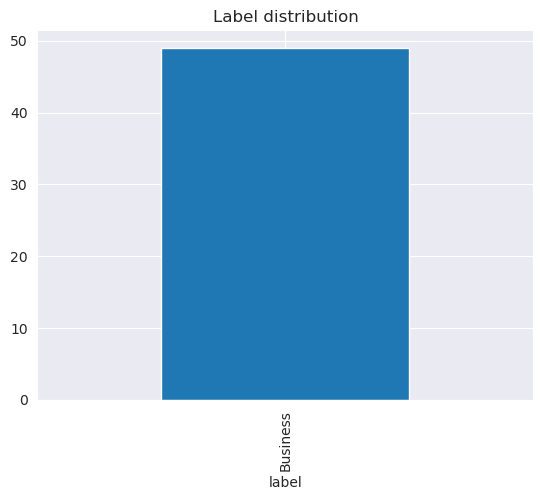

In [ ]:
df_responses = pd.DataFrame(generated_examples)
g = df_responses["label"].value_counts().plot(kind="bar", title="Label distribution")

In [10]:
generated_examples = []

for i in range(len(context_examples)):
    examples_str = "\n".join([f"- {item}" for item in context_examples[i]])
    for seed in range(5):
        set_seed(seed)
        prompt = f"""\
        Your task is to generate an high-quality short documents (around 30 words), that talks about one of the following four News categories (labels):
        {labels_str_bullet}.

        Here some examples of the documents you can use as a reference:
        {examples_str}

        Choose one of the categories (labels), generate the corresponding text and return it in the following JSON format:

        ```json
        {{
            "text": "<text of the document>", 
            "label": "<corresponding label>", 
        }}
        ```
        """
        messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": assistant_response},
            {"role": "user", "content": "The label is up to you."},
        ]
        response, delta_t = get_response("", model, tokenizer, messages=messages, apply_chat_template=True, max_new_tokens=1024, print_output=False, seed=seed)
        synthetic_data = response2json(response)
        generated_examples.append(synthetic_data)  
    
generated_examples = [ex for ex in generated_examples if ex]

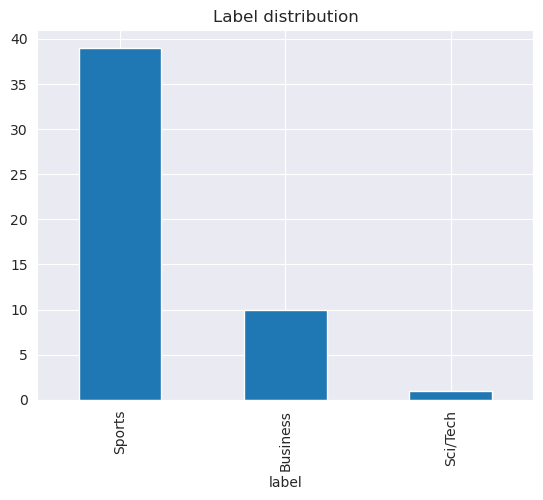

In [11]:
df_responses = pd.DataFrame(generated_examples)
g = df_responses["label"].value_counts().plot(kind="bar", title="Label distribution")